In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [14]:
import os
os.getcwd()


'/Users/satarupabanik/Documents/Elevate_Labs_Intern/DAY_5_Titanic_Dataset_EDA'

In [15]:
df = pd.read_csv('titanic/train.csv')


In [16]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [18]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
df.shape

(891, 12)

In [21]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [22]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

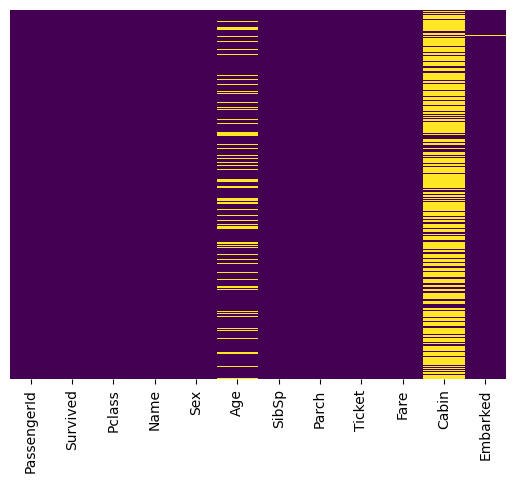

In [25]:
sns.heatmap(df.isnull(),yticklabels=False, cbar= False, cmap= 'viridis')

Looks like around 20% of the Age data is missing. That’s not ideal, but it’s manageable and we can probably fill in the gaps using some form of imputation without messing things up too much.
As for the Cabin column, we’re missing way too much data there to do anything meaningful with it right now. It might make more sense to either drop it entirely or convert it into something simpler, like a binary feature that just tells us whether the cabin info is available or not, for example, Cabin Known: 1 or 0.

/var/folders/1v/g6bcxzl16s587g__qbw3d0z00000gp/T/ipykernel_67679/2793448608.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived',data=df, palette='bright')


<Axes: xlabel='Survived', ylabel='count'>

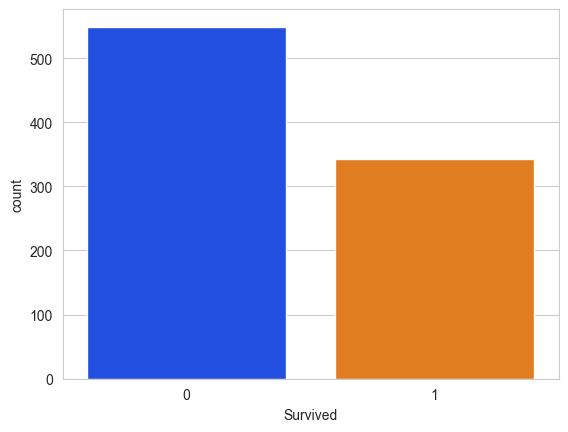

In [41]:
sns.set_style("whitegrid")
sns.countplot(x='Survived',data=df, palette='bright')

Looking at the countplot, we can see that over 550 people didn’t survive the Titanic disaster, while a little over 300 did make it.

<Axes: xlabel='Survived', ylabel='count'>

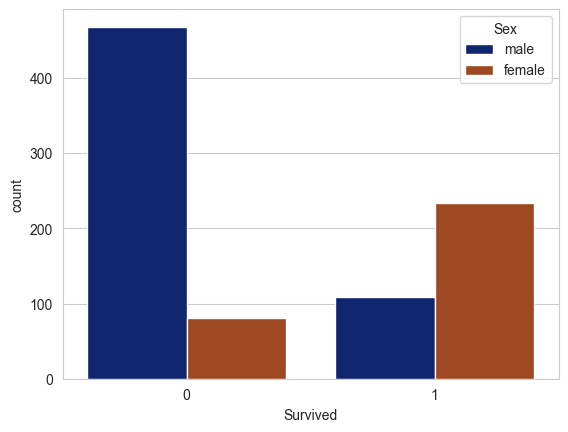

In [43]:
sns.set_style("whitegrid")
sns.countplot(x='Survived', hue = 'Sex', data= df, palette = 'dark')

From the plot, it's clear that over 450 men didn’t survive the sinking, while only around 100 women didn’t make it. On the flip side, more than 200 women survived, compared to about 150 men who made it through.

<Axes: xlabel='Survived', ylabel='count'>

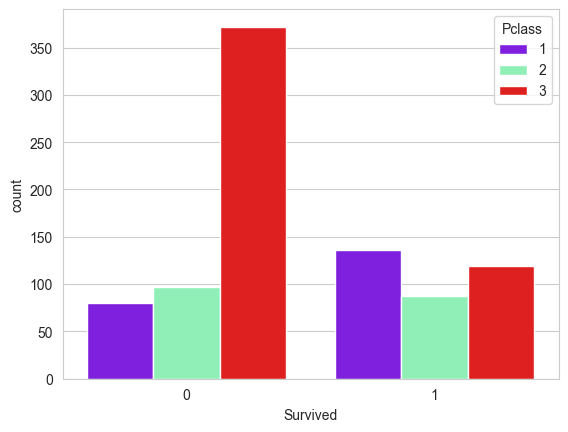

In [45]:
sns.set_style("whitegrid")
sns.countplot(x='Survived', hue = 'Pclass', data= df, palette = 'rainbow')

Class 1 (rich passengers) is represented in violet, Class 2 in green, and Class 3 in red. Passengers in higher classes had better chances of survival, with most non-survivors from third class

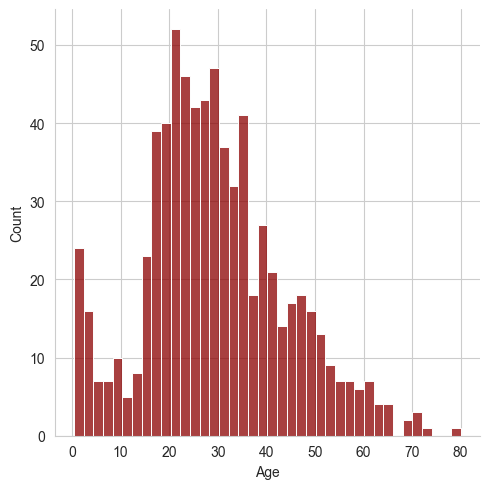

In [48]:
sns.displot(df["Age"].dropna(), kde= False, color= "darkred", bins=40)

The majority of passengers were between the ages of 17 and 35, with noticeably fewer elderly individuals on board.

/var/folders/1v/g6bcxzl16s587g__qbw3d0z00000gp/T/ipykernel_67679/2791497788.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SibSp', data= df, palette = 'muted')


<Axes: xlabel='SibSp', ylabel='count'>

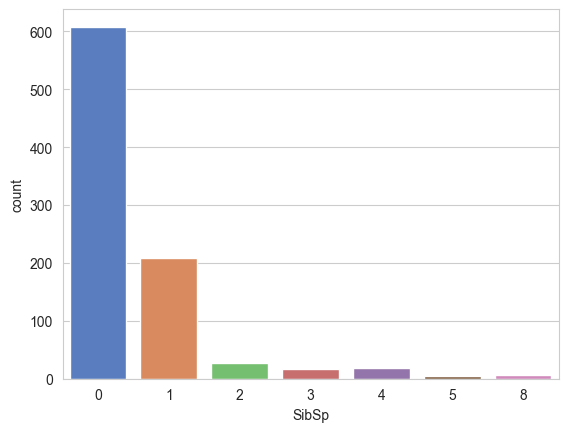

In [49]:
sns.set_style("whitegrid")
sns.countplot(x='SibSp', data= df, palette = 'muted')

Most passengers were traveling alone, with around 600 having no siblings or spouses aboard. In contrast, about 200 passengers had one sibling or spouse with them

<Axes: >

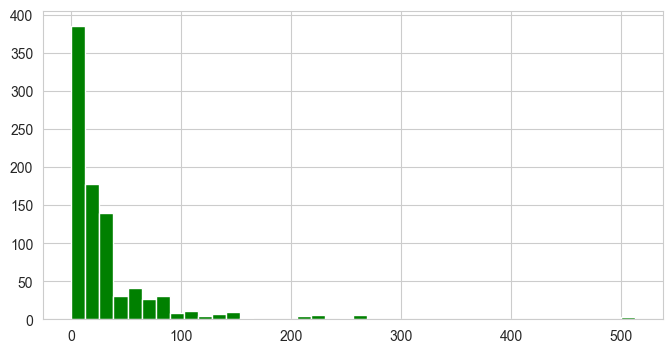

In [51]:
df["Fare"].hist(color= 'green',bins= 40, figsize =(8,4))

Most people on board paid relatively low fares. Around 400 passengers paid less than 50. As the fare increases, the number of passengers drops quickly. Only a few people paid more than 200 or 300

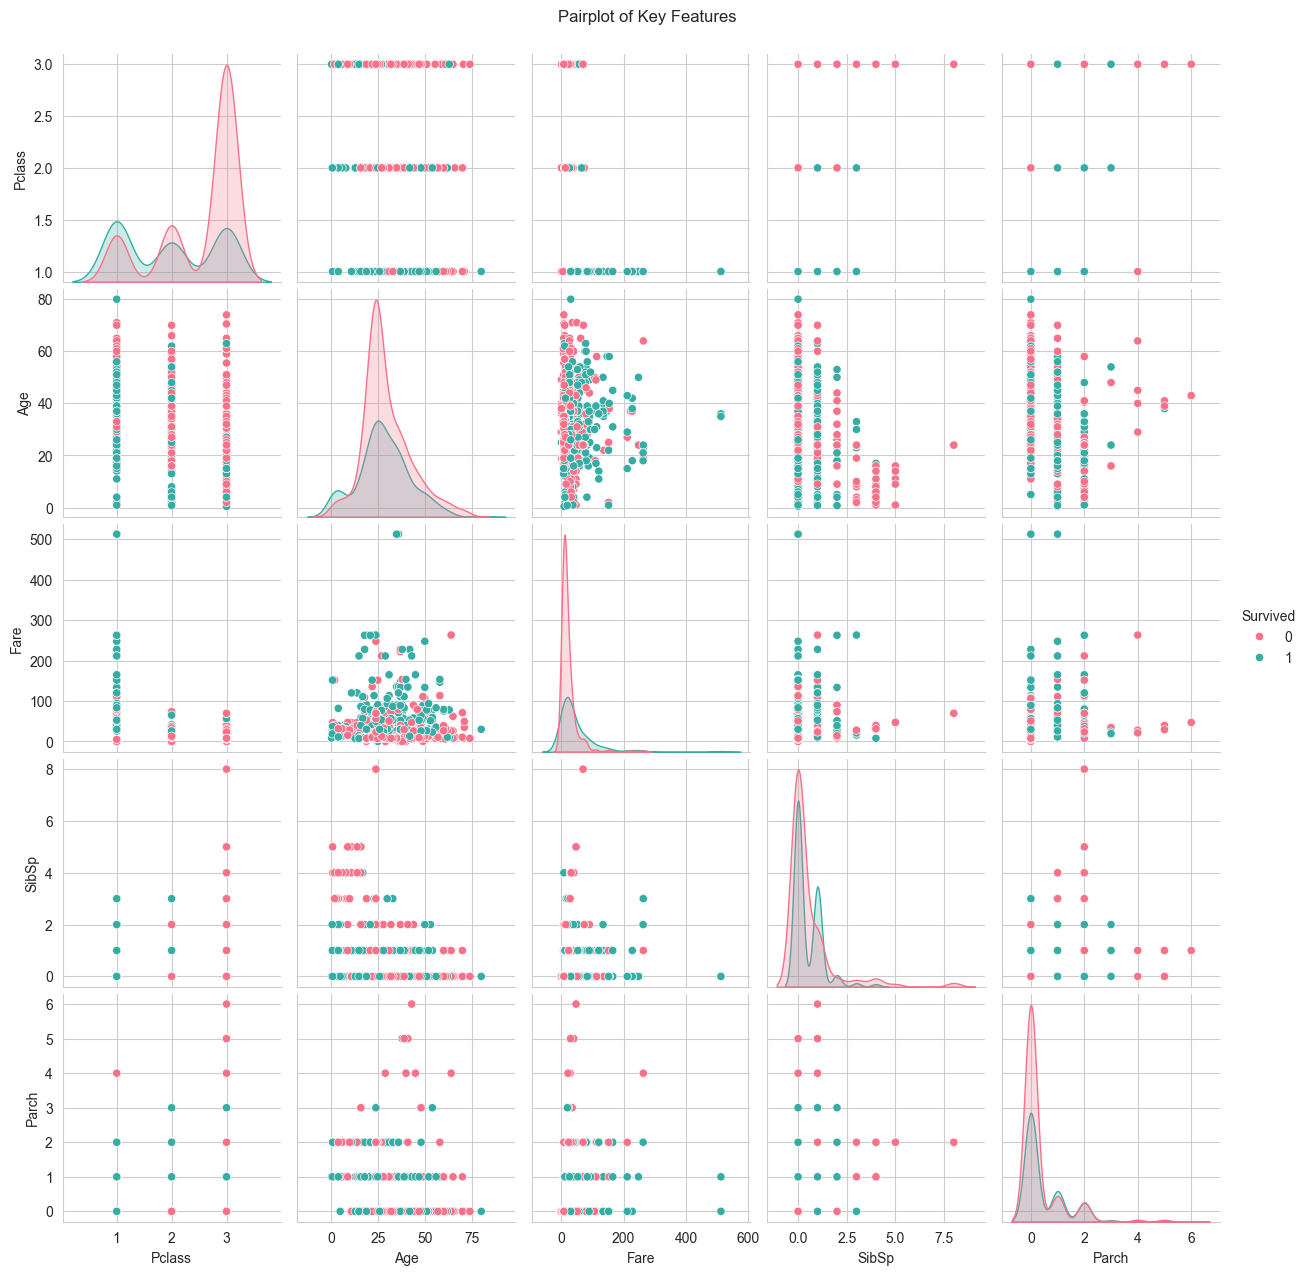

In [88]:
# To Select the most relevant columns
sns.pairplot(df[["Survived", "Pclass", "Age", "Fare", "SibSp", "Parch"]], hue="Survived", palette="husl")
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()


From the pairplot, it is evident that Pclass and Age show distinguishable patterns in relation to survival.

## Data Cleaning

/var/folders/1v/g6bcxzl16s587g__qbw3d0z00000gp/T/ipykernel_67679/2746316806.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y= 'Age', data =df, palette= 'winter')


<Axes: xlabel='Pclass', ylabel='Age'>

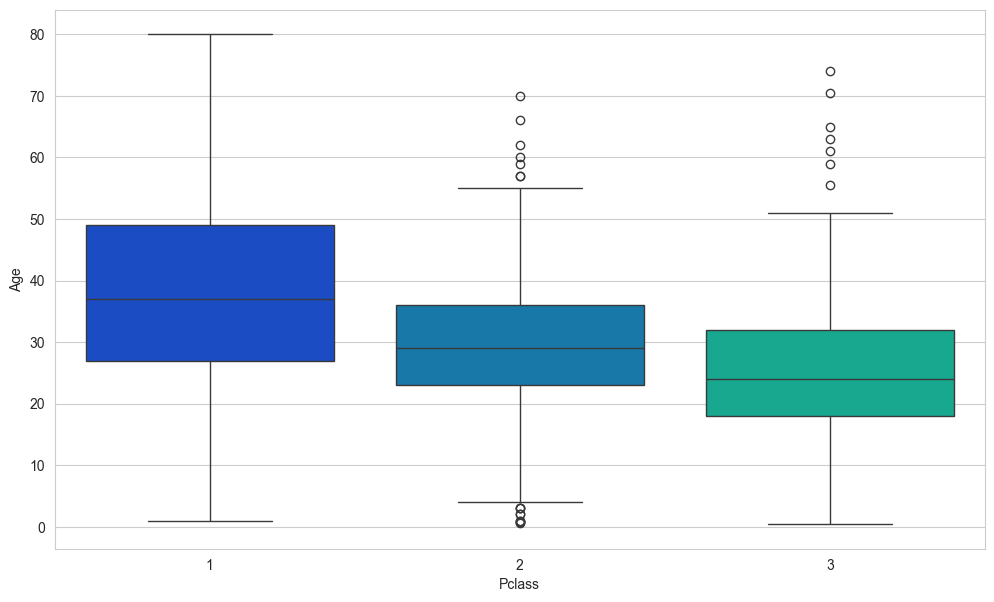

In [52]:
plt.figure(figsize=(12,7))
sns.boxplot(x='Pclass', y= 'Age', data =df, palette= 'winter')

I used a boxplot to check the relationship between passenger class and age. From this, we can see how the age distribution differs across the classes. This helps in estimating missing age values more accurately by using the average or median age for each class.

We can see that wealthier passengers in higher classes tend to be older, which makes sense. We'll use the average age within each class to fill in the missing age values accordingly.

In [53]:
def impute_age(cols):
    Age= cols[0]
    Pclass= cols[1]

    if pd.isnull(Age):
        if Pclass == 1:
            return 37

        elif Pclass ==2:
            return 29
        else:
            return 24

    else:
        return Age

In [56]:
df['Age'] = df[[ 'Age', 'Pclass']].apply(impute_age,axis=1)
                

/var/folders/1v/g6bcxzl16s587g__qbw3d0z00000gp/T/ipykernel_67679/2626717349.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age= cols[0]
/var/folders/1v/g6bcxzl16s587g__qbw3d0z00000gp/T/ipykernel_67679/2626717349.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass= cols[1]


We’re going to apply the average age for each Pclass to fill in the missing age values for passengers in that class.

<Axes: >

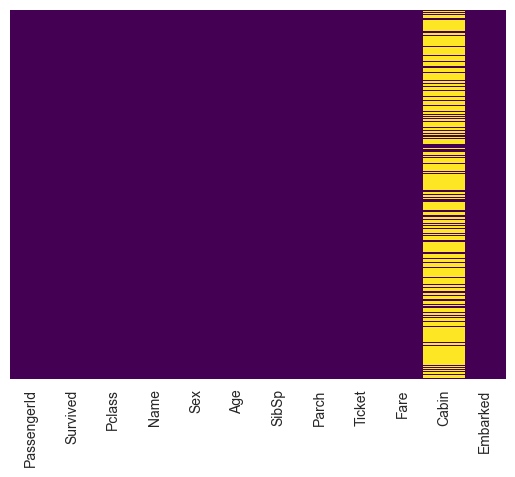

In [57]:
sns.heatmap(df.isnull(),yticklabels=False, cbar= False, cmap= 'viridis')

More than 70% values are missing in the Cabin column. So, we are going to drop the column.

In [58]:
df.drop('Cabin',axis=1,inplace = True)

In [61]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [60]:
df.dropna(inplace=True)

## Converting Categorical Features

We need to convert categorical features to dummy variables using pandas. Otherwise in future, ML algo won't be able to directly take in those features as inputs

 We will convert "Sex" and "Embarked" column into categorical columns

In [63]:
embark= pd.get_dummies(df['Embarked'],drop_first= True)

In [64]:
sex= pd.get_dummies(df['Sex'],drop_first= True)

Now we will drop the columns which wont be important for our further analysis

In [65]:
df.drop(['Sex','Embarked','Name','Ticket'], axis =1 , inplace = True)

In [66]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [68]:
df= pd.concat([df, sex, embark],axis=1)

In [70]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [71]:
df = df.astype({col: int for col in df.columns if df[col].dtype == bool})

In [72]:
df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


# Summary

Most passengers were from third class and paid low fares

Higher class passengers were older and had higher survival rates

Females had better survival chances than males

Age and fare distributions are skewed

## Building a Logistic Regression Model

In [74]:
df.drop('Survived',axis=1).head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,3,22.0,1,0,7.2500,1,0,1
1,2,1,38.0,1,0,71.2833,0,0,0
2,3,3,26.0,0,0,7.9250,0,0,1
3,4,1,35.0,1,0,53.1000,0,0,1
4,5,3,35.0,0,0,8.0500,1,0,1


In [75]:
df['Survived'].head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Survived',axis=1), df['Survived'], test_size=0.30, random_state=101)

## Training and Predicting

In [79]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)



LogisticRegression(max_iter=1000)

In [80]:
predictions= model.predict(X_test)

In [82]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [83]:
accuracy= confusion_matrix(y_test,predictions)

In [84]:
accuracy

array([[149,  14],
       [ 33,  71]])

In [85]:
accuracy= accuracy_score(y_test,predictions)

In [86]:
accuracy

0.8239700374531835

In [87]:
predictions

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1])

# Model Summary

I built a logistic regression model to predict passenger survival on the Titanic. After cleaning the data, handling missing values, and converting categorical features into binary format, I trained the model using 80% of the data and tested it on the remaining 20%.

The model achieved an accuracy of 82%, which means it correctly predicted survival for the majority of passengers in the test set. This shows that even a simple logistic regression can capture important patterns in the data — especially based on features like passenger class, gender, and age.

Further improvement could be done by scaling the features, trying other models like Random Forest or XGBoost, or fine-tuning hyperparameters.